In [1]:
import pickle
import os
import gpflow
import numpy as np
f64 = gpflow.utilities.to_default_float
import matplotlib.pylab as plt
import pandas as pd
import bambi as bmb
from matplotlib.ticker import MaxNLocator

In [3]:
for c in range(11):
    globals()[f'particles_summary{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/particles_summary{c}.pkl", mode="rb"))
    globals()[f'threshold{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/threshold{c}.pkl", mode="rb"))
    globals()[f'weight{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/weight{c}.pkl", mode="rb"))
    globals()[f'index{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/p_index_{c}.pkl", mode="rb"))
    globals()[f'mad{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/mad{c}.pkl", mode="rb"))
    globals()[f'r_s_mean{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/r_s_mean{c}.pkl", mode="rb"))
    globals()[f'r_s_median{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/r_s_median{c}.pkl", mode="rb"))

mad_all = np.vstack([globals()[f'mad{i}'] for i in range(11)])
threshold_all = np.vstack([globals()[f'threshold{i}'] for i in range(11)])
r_s_mean = np.vstack([globals()[f'r_s_mean{i}'] for i in range(11)])
r_s_median = np.vstack([globals()[f'r_s_median{i}'] for i in range(11)])


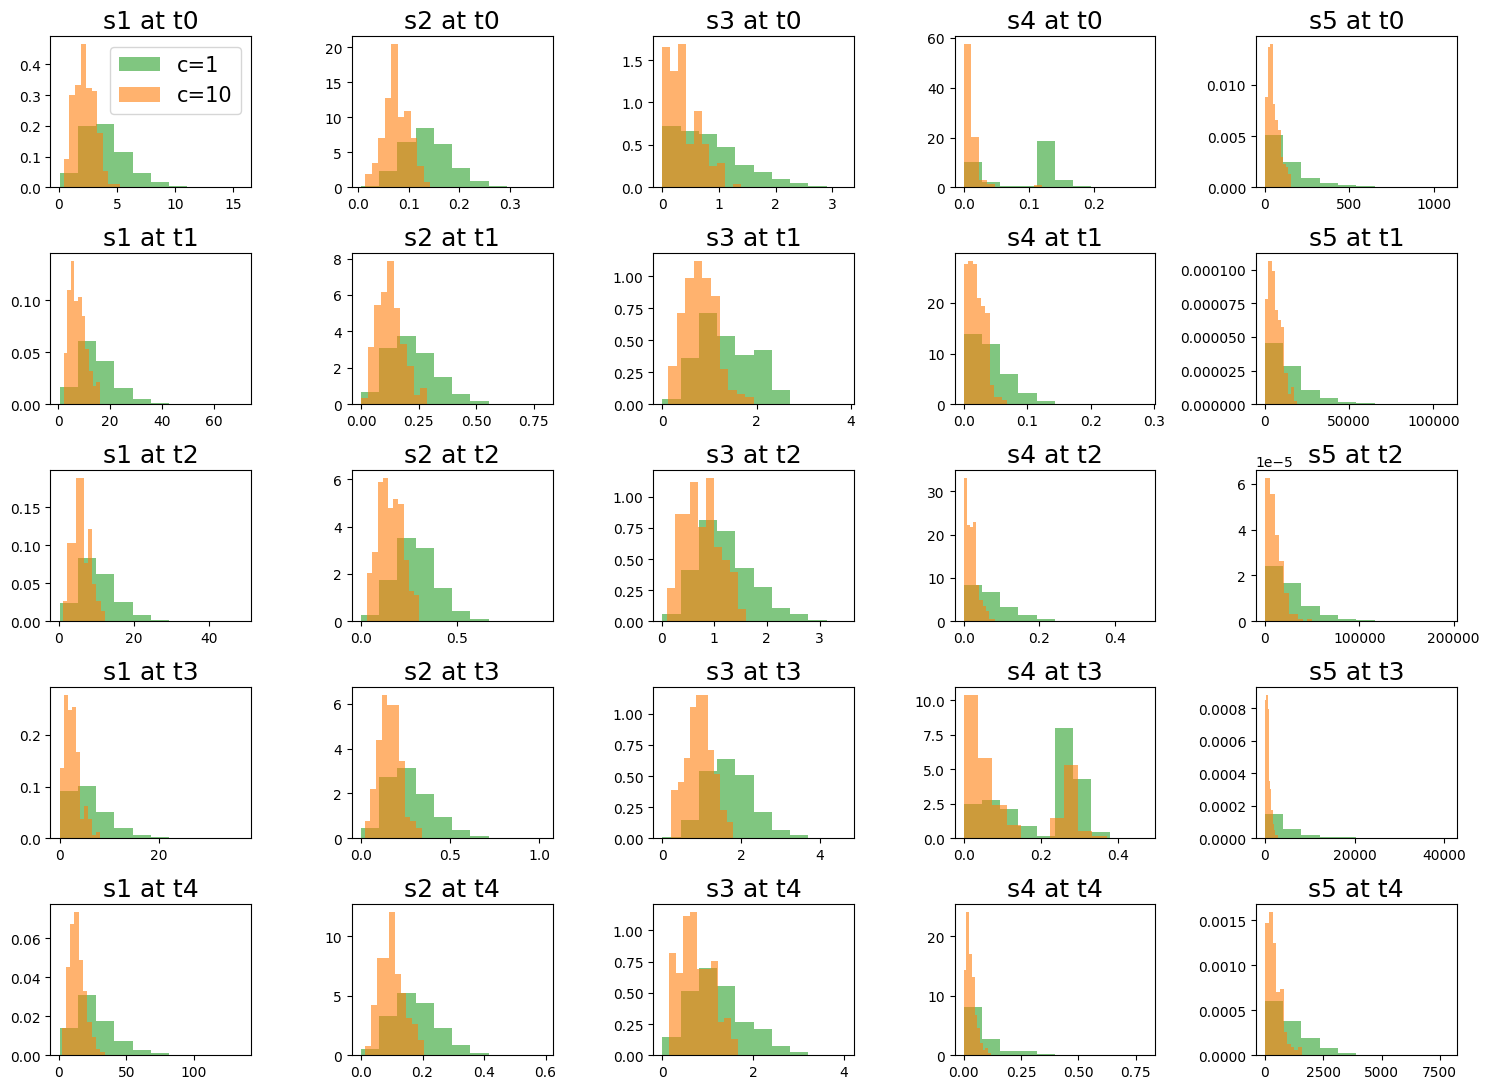

In [4]:
fig = plt.figure(figsize=(15, 11))
for j in range(25):
    ax = fig.add_subplot(5, 5, j+1)
    plt.title(f's{(j)%5+1} at t{(j)//5}', fontsize=18)

    plt.hist(globals()[f'particles_summary{1}'][:, j], color = f'C{2}', density=True, alpha=0.6, label=f'c={1}')
    plt.hist(globals()[f'particles_summary{10}'][:, j], color = f'C{1}', density=True, alpha=0.6, label=f'c={10}')
    if j == 0: plt.legend(fontsize=15)
plt.tight_layout()

plt.show()

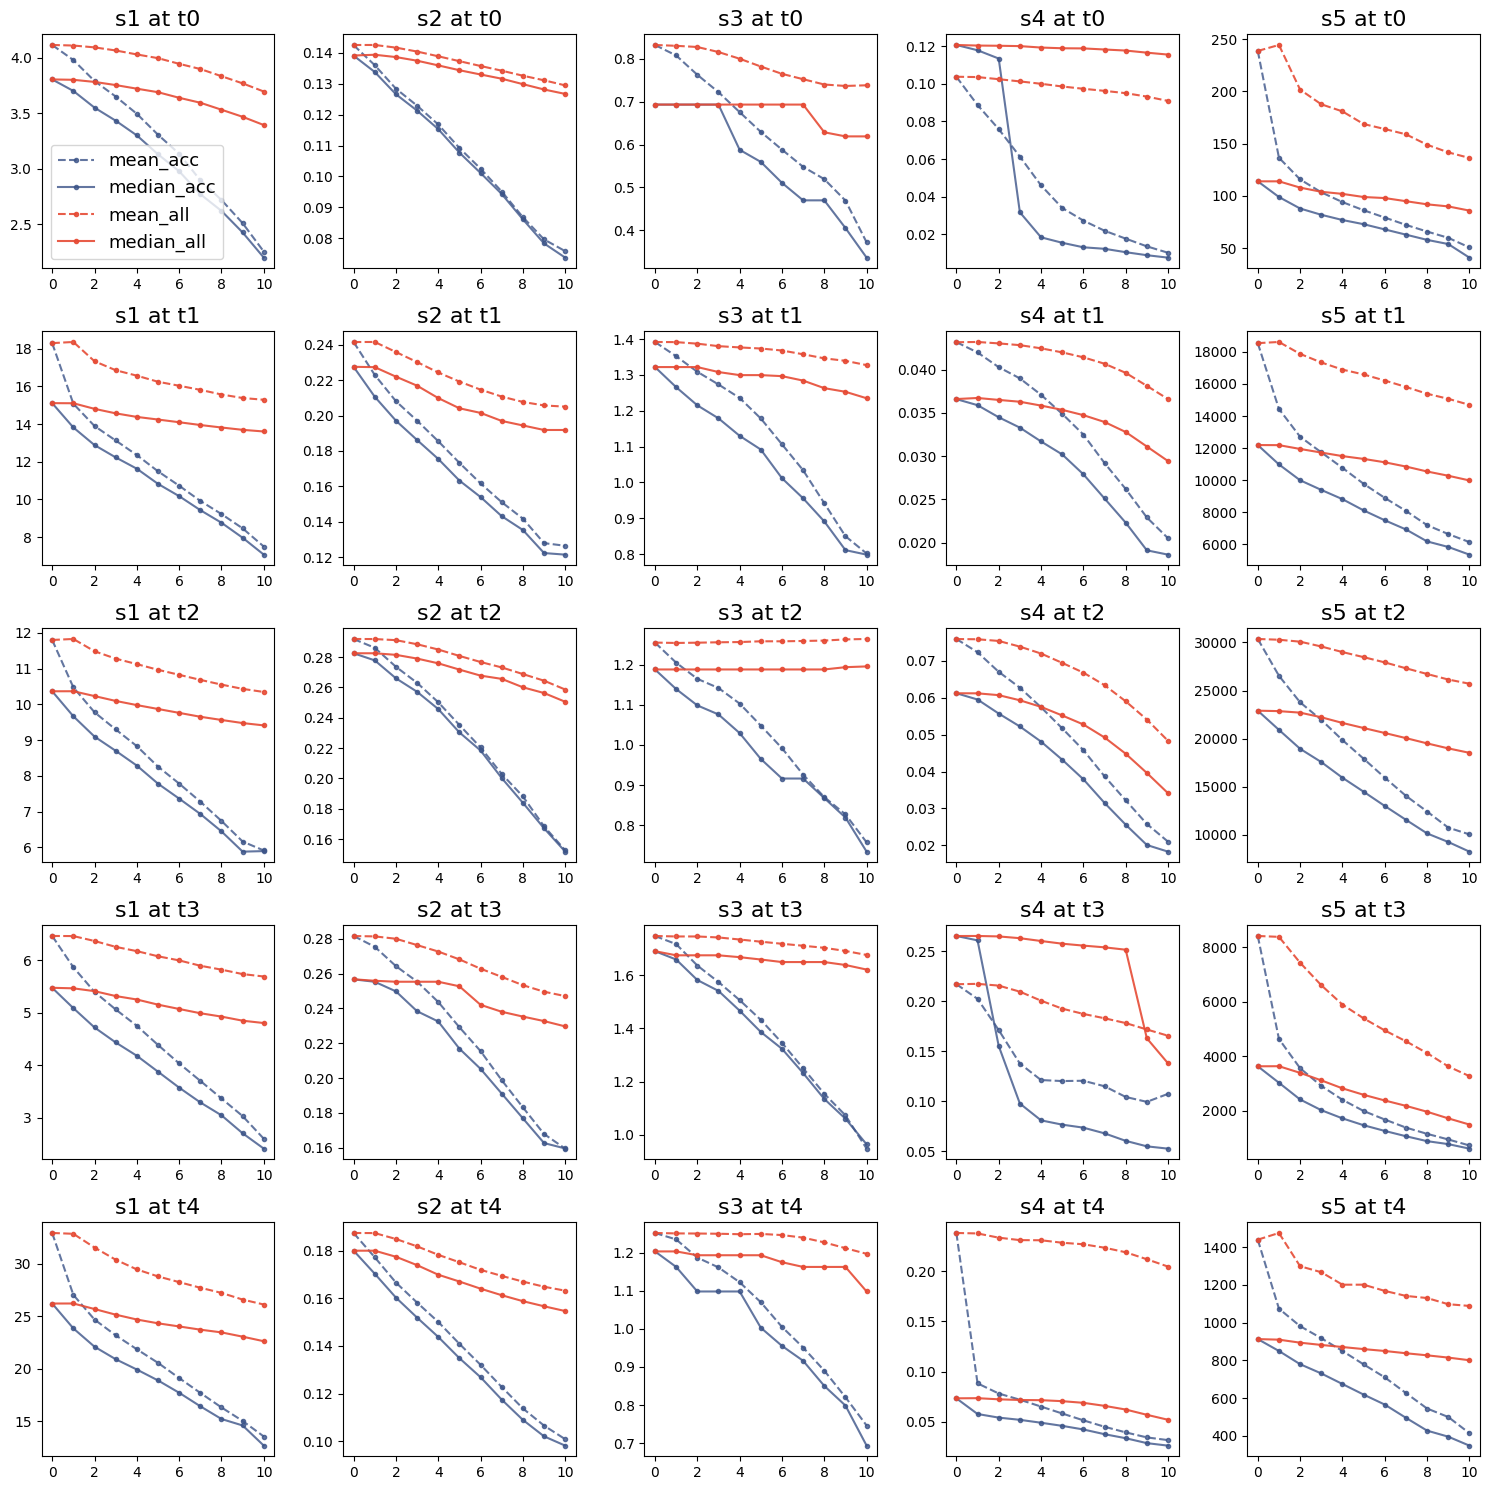

In [5]:
fig = plt.figure(figsize=(15, 15))
for j in range(25):
    ax = fig.add_subplot(5, 5, j+1)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    m0 = []
    m1 = []
    m2 = []
    for i in range(11):
        plt.title(f's{(j)%5+1} at t{(j)//5}', fontsize=16)
        m0.append(np.round(np.nanmean(globals()[f'particles_summary{i}'][:, j]), 4))
        m1.append(np.round(np.nanmedian(globals()[f'particles_summary{i}'][:, j]), 4))
    
    plt.plot(m0, '.--', label='mean_acc', color = '#3C5488', alpha=0.8)
    plt.plot(m1, '.-', label='median_acc', color = '#3C5488', alpha=0.8)

    plt.plot(r_s_mean[:, j], '.--', label='mean_all', color = '#E64B35', alpha=0.9)
    plt.plot(r_s_median[:, j], '.-', label='median_all', color = '#E64B35', alpha=0.9) 

    if j == 0: 
        plt.legend(fontsize=13)
plt.tight_layout()

plt.show()

In [6]:
for c in range(11):
    print(globals()[f'threshold{c}'])

21.006602792004394
18.461170377558293
17.053779692837985
15.595248523116808
14.186570665804481
13.024116407249648
11.884494664852724
10.908780500247202
9.994897270707046
9.13465612664616
8.641616078902263


In [ ]:
# ESS
for c in range(11):
    print(1 / np.sum(globals()[f'weight{c}'] ** 2))

In [7]:
for c in range(1, 10):
    neighbour =[] 
    current_index_simu = globals()[f'index{c}']
    for kk in range(current_index_simu.shape[0]): 
        neighbour.append(np.sum(np.sum(current_index_simu[kk] == current_index_simu, axis=1) >= 4)-1)

    print(np.sum(np.array(neighbour) > 0))

29533
35079
22949
18196
10161
4671
4499
2203
175


In [8]:
# unique
# 400017 

# 242956 
# 201538 
# 141148 
# 100471  

# 60241
# 30045 
# 20018
# 10010  
# 1600 
# 200

# unique - neighbour
print((400017 - 0)*5*5000) 
print((242956 - 29533)*5*5000) 
print((201538 - 35079)*5*5000) 
print((141148 - 22949)*5*5000) 
print((100471- 18196)*5*5000) 
print((60241 - 10161)*5*5000)
print((30045 - 4671)*5*5000)
print((20018  - 4499)*5*5000)
print((10010 - 2203)*5*5000)
print((2000 - 175)*5*5000)

10000425000
5335575000
4161475000
2954975000
2056875000
1252000000
634350000
387975000
195175000
45625000


In [9]:
# ESS - neighbour
print((400016.99999999953 - 0)*5*5000) 
print((242959.0 - 29533)*5*5000) 
print((200154.37170540926 - 35079)*5*5000) 
print((137695.4568920147 - 22949)*5*5000) 
print((96199.2475177572 - 18196)*5*5000) 
print((56418.90361673603 - 10161)*5*5000)
print((27285.015767077482 - 4671)*5*5000)
print((17751.382779540036  - 4499)*5*5000)
print((8366.189878351921 - 2203)*5*5000)
print((1235.8723276860442  - 175)*5*5000)


10000424999.999989
5335650000.0
4126884292.6352315
2868661422.300368
1950081187.9439304
1156447590.4184008
565350394.176937
331309569.48850083
154079746.95879802
26521808.192151103


In [10]:
# accp 
# 400017 

# 242959 
# 201541 
# 141150 
# 100473 

# 60241
# 30046
# 20018
# 10012  
# 1600 
# 200

# acc rate
print(242959/440000)
print(201541/670000)
print(141150/890000)
print(100473/1270000)
print(60241/1710000)
print(30046/2180000)
print(20018/5390000)
print(10012/11900000)
print(1600/11410000)
print(200/9790000)

0.5521795454545455
0.30080746268656716
0.15859550561797753
0.07911259842519686
0.035228654970760234
0.013782568807339449
0.0037139146567717997
0.000841344537815126
0.00014022787028922
2.0429009193054138e-05


In [15]:
p_accpt = [1, 0.5522, 0.3008, 0.1586, 0.0791, 0.0352, 0.0138, 0.0037, 8.413*10**(-4), 1.402*10**(-4), 2.043*10**(-5)]

In [11]:
# producing plot based on summary0 from many source

summary0 = np.load(open(file = os.getcwd()+f"/ABC_details/s0_random/particles_summary006463011.pkl", mode="rb"))
summary0 = np.concatenate([summary0, 
                           np.load(open(file = os.getcwd()+f"/ABC_details/s0_random/particles_summary015282210.pkl", mode="rb"))])
summary0 = np.concatenate([summary0, 
                           np.load(open(file = os.getcwd()+f"/ABC_details/s0_random/particles_summary004434411.pkl", mode="rb"))])
summary0 = np.concatenate([summary0, 
                           np.load(open(file = os.getcwd()+f"/ABC_details/s0_random/particles_summary003485713.pkl", mode="rb"))])
summary0 = np.concatenate([summary0, 
                           np.load(open(file = os.getcwd()+f"/ABC_details/s0_random/particles_summary022061711.pkl", mode="rb"))])
summary0 = np.concatenate([summary0, 
                           np.load(open(file = os.getcwd()+f"/ABC_details/s0_random/particles_summary015282210.pkl", mode="rb"))])
summary0 = np.concatenate([summary0, 
                           np.load(open(file = os.getcwd()+f"/ABC_details/s0_random/particles_summary010085710.pkl", mode="rb"))])
summary0 = np.concatenate([summary0, 
                           np.load(open(file = os.getcwd()+f"/ABC_details/s0_random/particles_summary013275912.pkl", mode="rb"))])
summary0 = np.concatenate([summary0, 
                           np.load(open(file = os.getcwd()+f"/ABC_details/s0_random/particles_summary023170011.pkl", mode="rb"))])
summary0 = np.concatenate([summary0, 
                           np.load(open(file = os.getcwd()+f"/ABC_details/s0_random/particles_summary000115510.pkl", mode="rb"))])

p_prior = [1]
number_prior = [10000190]
for i in range(1, 11):
    p_prior.append(np.mean(np.sqrt(np.sum((summary0/globals()[f'mad{i-1}'])**2, axis=1)) < globals()[f'threshold{i-1}']))
    number_prior.append(np.sum(np.sqrt(np.sum((summary0/globals()[f'mad{i-1}'])**2, axis=1)) < globals()[f'threshold{i-1}']))

In [13]:
print(number_prior)
print(p_prior)

[10000190, 5510141, 2746047, 1215270, 462395, 151551, 41057, 6966, 820, 77, 4]
[1, 0.5510036309310123, 0.2745994826098304, 0.12152469103087041, 0.04623862146619214, 0.015154812058570888, 0.00410562199318213, 0.0006965867648514679, 8.199844202960144e-05, 7.699853702779647e-06, 3.9999240014439725e-07]


In [17]:
t_c = np.array([96.35 , 152.85, 190.27 , 236.50, 326.55, 433.95, 550.62, 1362.4, 3018.8, 2903.7, 2489.9])
cum_t_c = np.cumsum(t_c)
N_c = np.array([400017, 242959,  201541, 141150, 100473,  60241, 30046, 20018,  10012,  1600, 200 ])
E_c1 = number_prior * (cum_t_c / 2541)
E_c2 = number_prior * (t_c / 2541)
t_E = (N_c/number_prior) * 2541

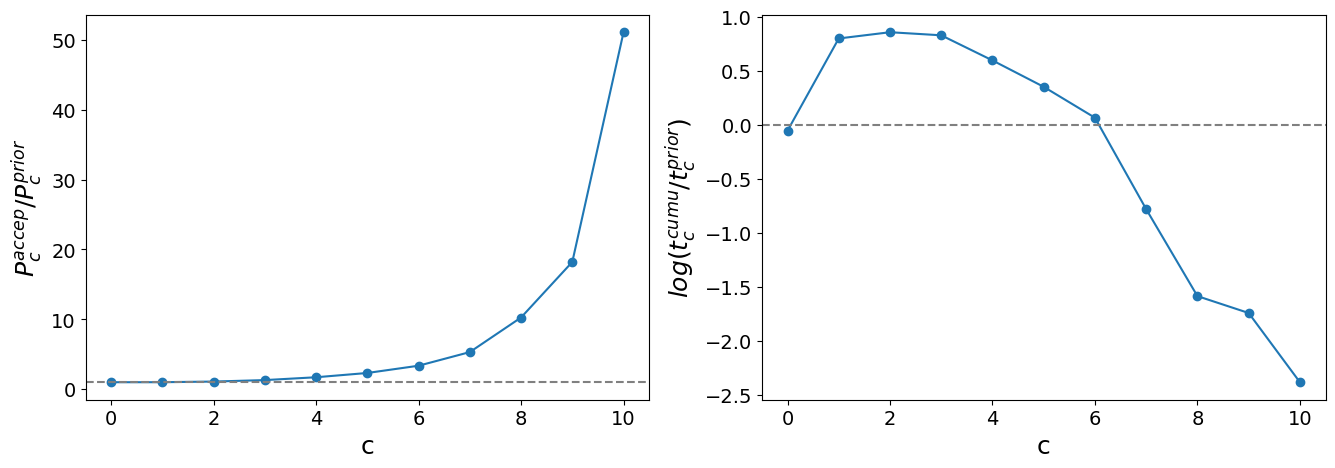

In [20]:
fig = plt.figure(figsize=(16, 5))
ax = fig.add_subplot(1, 2, 1)

plt.plot(np.array(p_accpt)/np.array(p_prior), '-o')
plt.ylabel(r"$P^{accep}_c"+"     /       " +r"P_{c}^{prior}$", fontsize=18)
plt.xlabel('c', fontsize=18)
plt.axhline(1, linestyle='--', color='grey')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax = fig.add_subplot(1, 2, 2)

plt.plot(np.log(cum_t_c/t_E), '-o')
# plt.plot(N_c/E_c2, '-o')
plt.ylabel(r"$log(t^{cumu}_c"+"     /       " +r"t_{c}^{prior})$", fontsize=18)
plt.xlabel('c', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.axhline(0, linestyle='--', color='grey')
# plt.savefig('plot13.pdf')  
